# Worksheet 4 - Scientific Visualisation MVE080/MMG640
## Part 1: Uncertainty and storytelling with data

Names of all group members: Elis Åhlund, Erik Dagobert, Yixuan Pan

This is the first worksheet in the course *Scientific Visualisation*. This Jupyter notebook has three functions:

1. It describes the tasks.
2. It (sometimes) provides coding templates that you can use as a basis for your own code.
3. It is a template also for the report that you upload in Canvas.

The tasks are of various types: some are to read some text and then comment on it (no coding), and some are about creating visualisations using plotnine. Once you have finished all the tasks, export this document as an HTML file and upload it in Canvas. 

The goal of these homeworks is to learn how to improve your skills in visualising your science. You solve the homeworks in groups, however annotate all the code (even the theoretical parts) with who solved each question. **Eventhough the homework is submitted as a group you will be *individually* evaluated**. Motivate your choice of graph, legend, colourmap etc below your graph in a separate cell. 

Notice that Jupyter notebooks use [Markdown](https://docs.github.com/en/github/writing-on-github/getting-started-with-writing-and-formatting-on-github/basic-writing-and-formatting-syntax#links) for writing text cells. Make sure you understand the basics. 

Throughout the assignment you shall use a Python workflow.
If you are completely new to Python, take a look at [this page](pythonbasics.org).
Python can do essentially all that MATLAB can, plus more. 
In this course we shall use Python in different contexts, starting with the [Jupyter Notebook interface](https://jupyter-notebook.readthedocs.io/en/stable/notebook.html). 

Matrices and arrays are handled through the NumPy module. [Learn here](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html) how NumPy is different from MATLAB.

The below loads the packages required for this homework.

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
from plotnine import *
# Currently in a plotine dependancy they have deprication warning, so 
# we mute warnings to have a better experience
import warnings
warnings.filterwarnings("ignore")

# A nice color palette for categorical data 
cbPalette = ["#E69F00", "#56B4E9", "#009E73", 
             "#F0E442", "#0072B2", "#D55E00", 
             "#CC79A7", "#999999"]

## Task 1

Read Chapter 16 of [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/), then answer the questions below.

### Question 1.1

During Lecture 6, we visualised uncertainty for point estimates using i) graded error bars and ii) fuzziness (slide 7). Briefly describe when each kind of visual is suitable.

### Answer 1.1
#Elis
A graded error bar is suitable when there are set or more constrained limits for each side of the bar which shows that the date does not exceed the specified amount. Fuzziness is better when visualising that the data could exceed to an unspecified amount, while also could show that the outer data values are less important.

### Question 1.2

Another way to visualise uncertainty is a **Hypothetical outcome plots** (Chapter 16 in [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/)). Briefly describe the key features of such a visual.

### Answer 1.2
#Erik 
A HOP is a way of illustrating uncertainty in data by curating a representative selection of possible visuals and showing them as an animation (GIF or video) instead of ploting their likelihoods/uncertainty all in a single visual. This can be an effective way of preventing deterministic construal error, when the reader misinterprets uncertainty visuals as a deterministic aspect of the data. 

### Question 1.3

Often when doing regression (fitting a curve to data), we want to use the regression model to make predictions. What is important to think about when visualising model predictions?

### Answer 1.3

#Yixuan
We can add multiple layers to visualize different confidence intervals and error bars. Alternatively, show several representative fits.  A fan chart are more efficient when doing regression.

## Uncertainty  

For this part reading chapter 16 in [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/) can help.

### Question 2.1

Coffee is undoubtedly a popular beverage. On Canvas, I have uploaded a dataset with ratings for coffee beans from six different countries. 

Here, we are interested in identifying which country on average has the best quality beans. Create two plots, where in i) you plot the mean ($\mu$) and standard deviation for each country (using error bars), and ii) where you plot the mean and standard error of the mean estimate. Briefly discuss the drawbacks with error bars. 

As a reminder. For country $j$ with coffee ratings $x^{(j)}_1, \ldots, x^{(j)}_{n_j}$ the sample mean is given by 

$$
\hat{\mu}^{(j)} = \sum_{i = 1}^{n_j} x_i^{(j)},
$$

sample standard deviation by

$$
\hat{\sigma}^{(j)} = \sqrt{\frac{1}{n - 1} \sum_{i = 1}^{n_j} (x_i^{(j)} - \hat{\mu}^{(j)})^2},
$$

and sample standard error for $\hat{\mu}^{(j)}$

$$
\hat{\sigma}_{\hat{\mu}^{(j)}} = \frac{\hat{\sigma}^{(j)}}{\sqrt{n}}
$$

and a confidence interval with confidence level $1 - \alpha$ is given by;

$$
\hat{\mu}^{(j)} \pm t_{n-1}(1 - \alpha / 2) \hat{\sigma}_{\hat{\mu}^{(j)}}
$$

where $t_{n-1}$ is the t-distribution with $n-1$ degree of freedom. For confidence level $1 - \alpha=0.95$ and $n = 30$ we have that $t_{29}(1 - 0.025) \approx 2.05$.

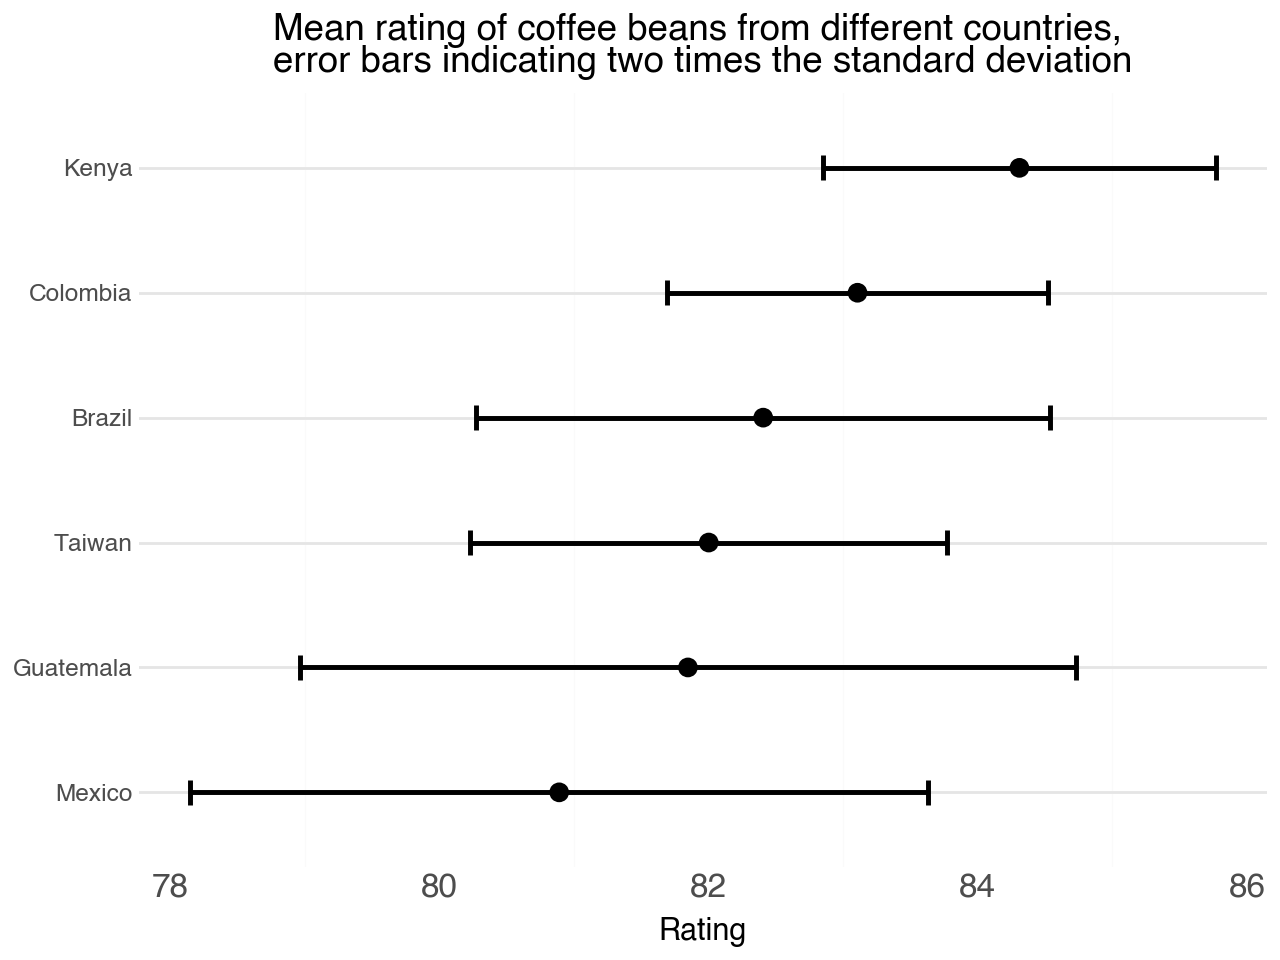

In [3]:
# Insert code here for visual 1
#Erik

data_coffee = pd.read_csv("Coffee_tidy.csv")

size = data_coffee.groupby("country_of_origin").size()
size_sqrt = np.sqrt(data_coffee.groupby("country_of_origin").size())


# Calculate summary statistics: 
data_coffee = data_coffee.groupby("country_of_origin").agg(
    {
        "total_cup_points": ["mean", "std"],
        "country_of_origin": ["size"]
    }
)

data_coffee["ymin"] = data_coffee[("total_cup_points", "mean")] - data_coffee[("total_cup_points", "std")]
data_coffee["ymax"] = data_coffee[("total_cup_points", "mean")] + data_coffee[("total_cup_points", "std")]

# Get rid of multi-indexing:
data_coffee = data_coffee.reset_index()
data_coffee.columns = [''.join(col) for col in data_coffee.columns]

countries = ["Mexico", "Guatemala", "Taiwan", "Brazil", "Colombia", "Kenya"]
data_coffee["country_of_origin"] = pd.Categorical(data_coffee["country_of_origin"], categories=countries, ordered=True)

(
    ggplot(data_coffee, aes("country_of_origin", "total_cup_pointsmean"))
        + geom_point(size=3.0)
        + geom_errorbar(aes(ymin="ymin", ymax="ymax"), width=0.2, size=1.0)
        + labs(x = "", y = "Rating", 
               title = "Mean rating of coffee beans from different countries, \nerror bars indicating two times the standard deviation")
        + theme_minimal()
        + coord_flip()
        + theme(panel_grid_major_x=element_blank(),
            axis_text_x = element_text(size=12))
)

# Remember to print the visual 

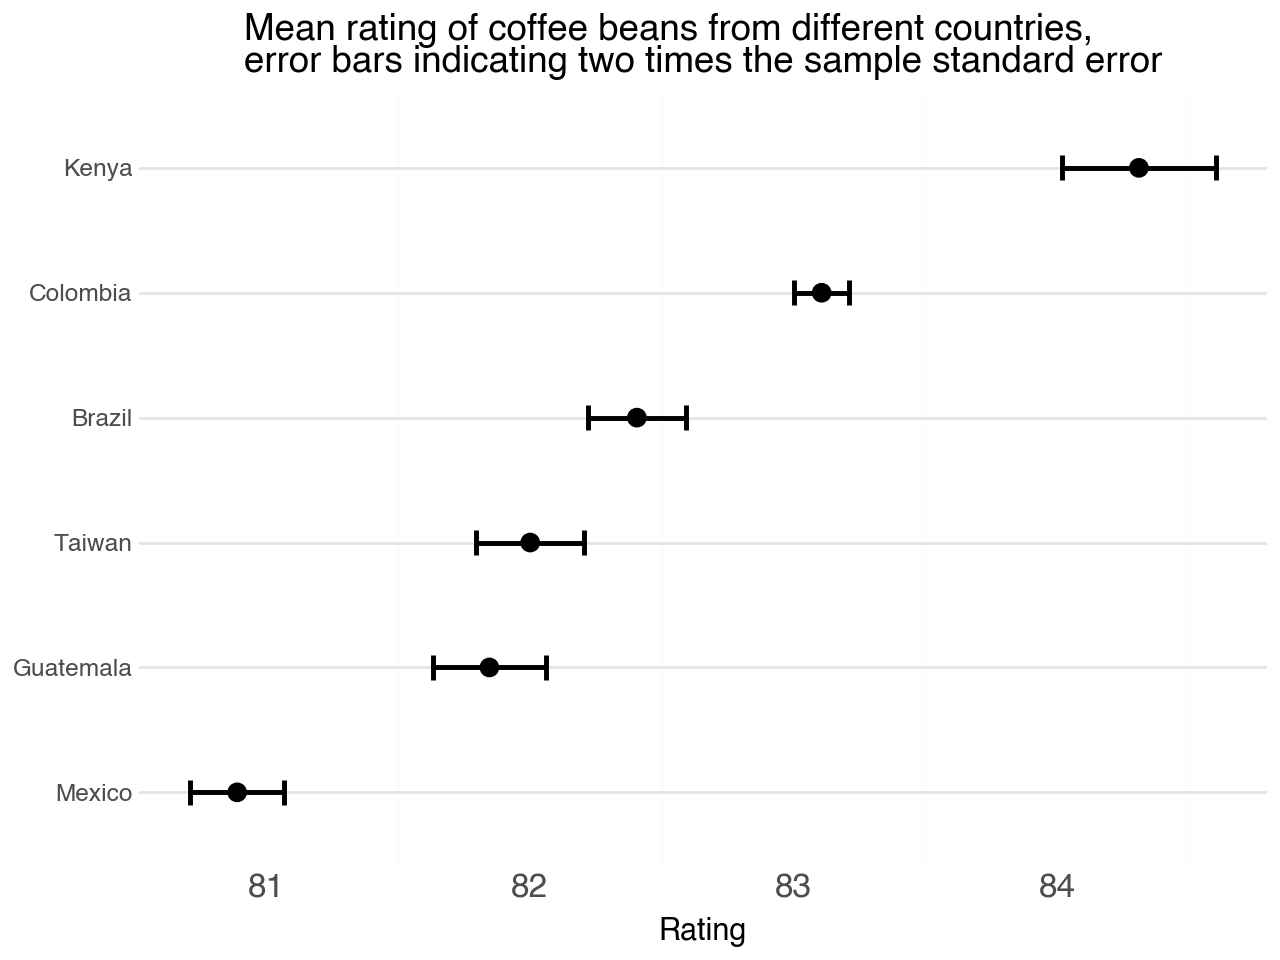

In [4]:
# Insert code here for visual 2
# Erik

data_coffee["std_error"] = data_coffee["total_cup_pointsstd"] / np.sqrt(data_coffee["country_of_originsize"])

data_coffee["ymin_err"] = data_coffee["total_cup_pointsmean"] - data_coffee["std_error"]
data_coffee["ymax_err"] = data_coffee["total_cup_pointsmean"] + data_coffee["std_error"]


(
    ggplot(data_coffee, aes("country_of_origin", "total_cup_pointsmean"))
        + geom_point(size=3.0)
        + geom_errorbar(aes(ymin="ymin_err", ymax="ymax_err"), width=0.2, size=1.0)
        + labs(x = "", y = "Rating", 
               title = "Mean rating of coffee beans from different countries, \nerror bars indicating two times the sample standard error")
        + theme_minimal()
        + coord_flip()
        + theme(panel_grid_major_x=element_blank(),
            axis_text_x = element_text(size=12))
)



# Remember to print the visual 

#Erik
Error bars are an additional source of information in a visual which can be helpful but also extra clutter. It is also not immediately clear from just looking at a visual (without reading some text) what the error bars represent, for example the standard deviation or the standard error. A layman might think that they denote the lowest and highest observed values or possible span for a parameter estimate. Even if a layman decodes what the error bars represent, it can still be hard for them to interpret the uncertainty/population spread they are supposed to inform about. It can sometimes be more intuitive to use a HOP or some other visual in such cases. 

### Question 2.2

Now using the coffee dataset, visualise the uncertainty in the mean estimate using i) graded error bars (here, plot confidence intervals with 80%, 90% and 99% confidence) and ii) fuzzy error bars (as on slide 7 in Lecture 6).

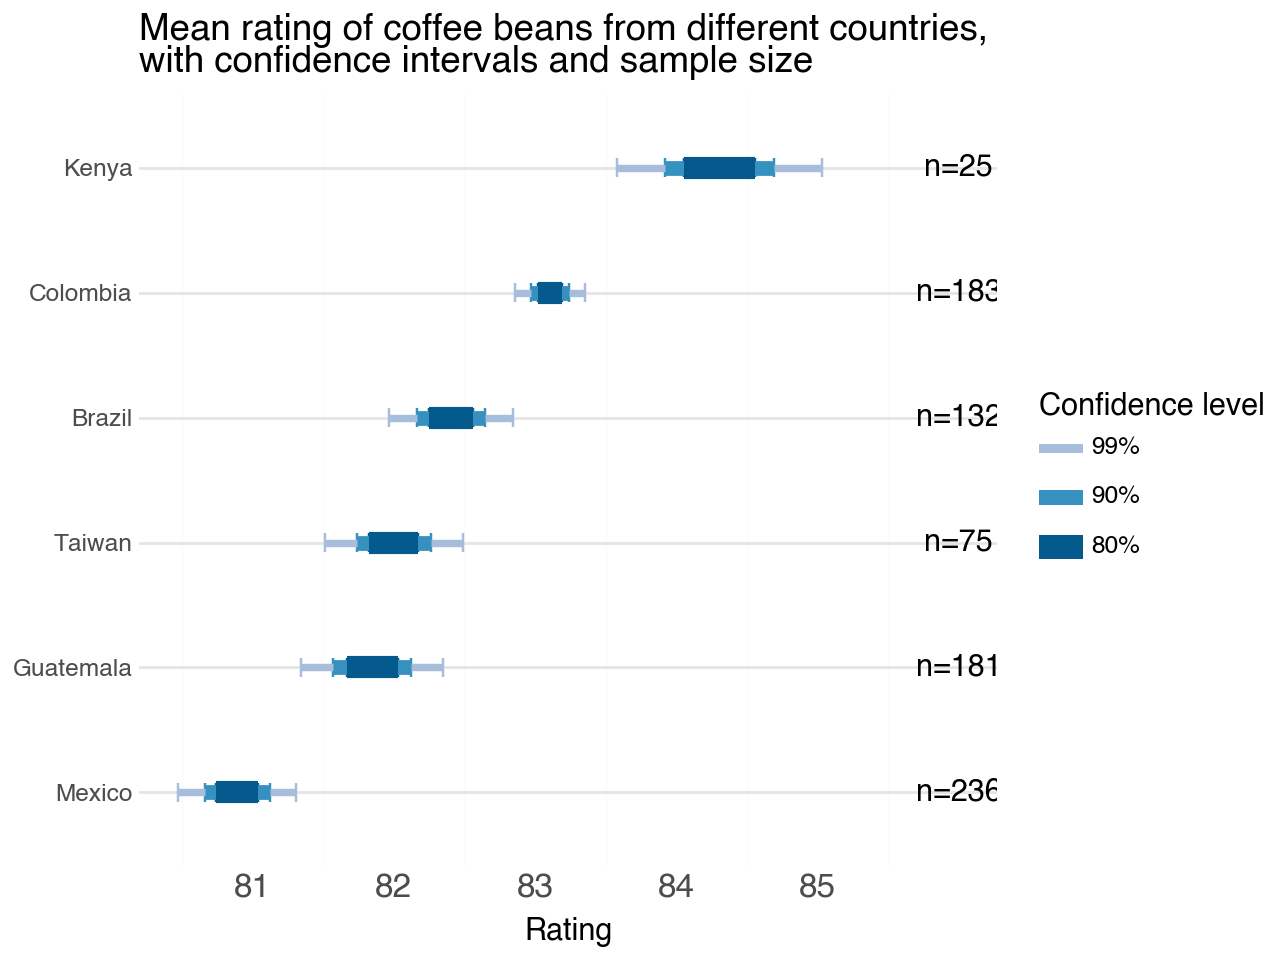

In [5]:
# Insert code here for visual 1
# Erik

# Calculate CIs:
CI_percent = ["80%", "90%", "99%"]

arrays = [
    countries,
    CI_percent
]

# t-values from table:
ts = [0.84, 1.29, 2.35, 0.84, 1.29, 2.35, 0.85, 1.29, 2.38, 0.84, 1.29, 2.35, 0.84, 1.29, 2.35, 0.86, 1.32, 2.49]

index = pd.MultiIndex.from_product(arrays, names=["country_of_origin", "CI_percent"])

CIs = pd.DataFrame(ts, index=index, columns=["t"])

CIs = CIs.join(
    data_coffee[["country_of_origin", "total_cup_pointsmean", "std_error"]].set_index('country_of_origin'), 
    on='country_of_origin')

CIs["CI_low"]  = CIs["total_cup_pointsmean"] - CIs["t"] * CIs["std_error"]
CIs["CI_high"] = CIs["total_cup_pointsmean"] + CIs["t"] * CIs["std_error"]

CIs = CIs.reset_index()
CIs.columns = [''.join(col) for col in CIs.columns]

# Reorder CI_percent
CIs["CI_percent"] = pd.Categorical(CIs["CI_percent"], categories=["99%", "90%", "80%"], ordered=True)

CIs["country_of_origin"] = pd.Categorical(CIs["country_of_origin"], categories=countries, ordered=True)


(
    ggplot(CIs, aes(x = "country_of_origin")) 
      + geom_errorbar(aes(ymin = "CI_low", ymax = "CI_high", color = "CI_percent"), width=0.15)
      + geom_errorbar(aes(ymin = "CI_low", ymax = "CI_high", size = "CI_percent", color="CI_percent", width=0.0))
      + scale_color_manual(values = ["#a6bddb", "#3690c0", "#045a8d"], name = "Confidence level")
      + annotate("text", x = "Brazil", y = 86, label = "n=132")
      + annotate("text", x = "Colombia", y = 86, label = "n=183")
      + annotate("text", x = "Guatemala", y = 86, label = "n=181")
      + annotate("text", x = "Kenya", y = 86, label = "n=25")
      + annotate("text", x = "Mexico", y = 86, label = "n=236")
      + annotate("text", x = "Taiwan", y = 86, label = "n=75")
      + scale_size_manual(values = [1.5, 3.0, 4.5], name = "Confidence level")
      + labs(x = "", y = "Rating", title = "Mean rating of coffee beans from different countries, \nwith confidence intervals and sample size")
      + theme_minimal()
      + coord_flip()
      + scale_y_continuous(breaks=[80, 81, 82, 83, 84, 85])
      + theme(panel_grid_major_x=element_blank(),
          axis_text_x = element_text(size=12))
)
# Remember to print the visual 

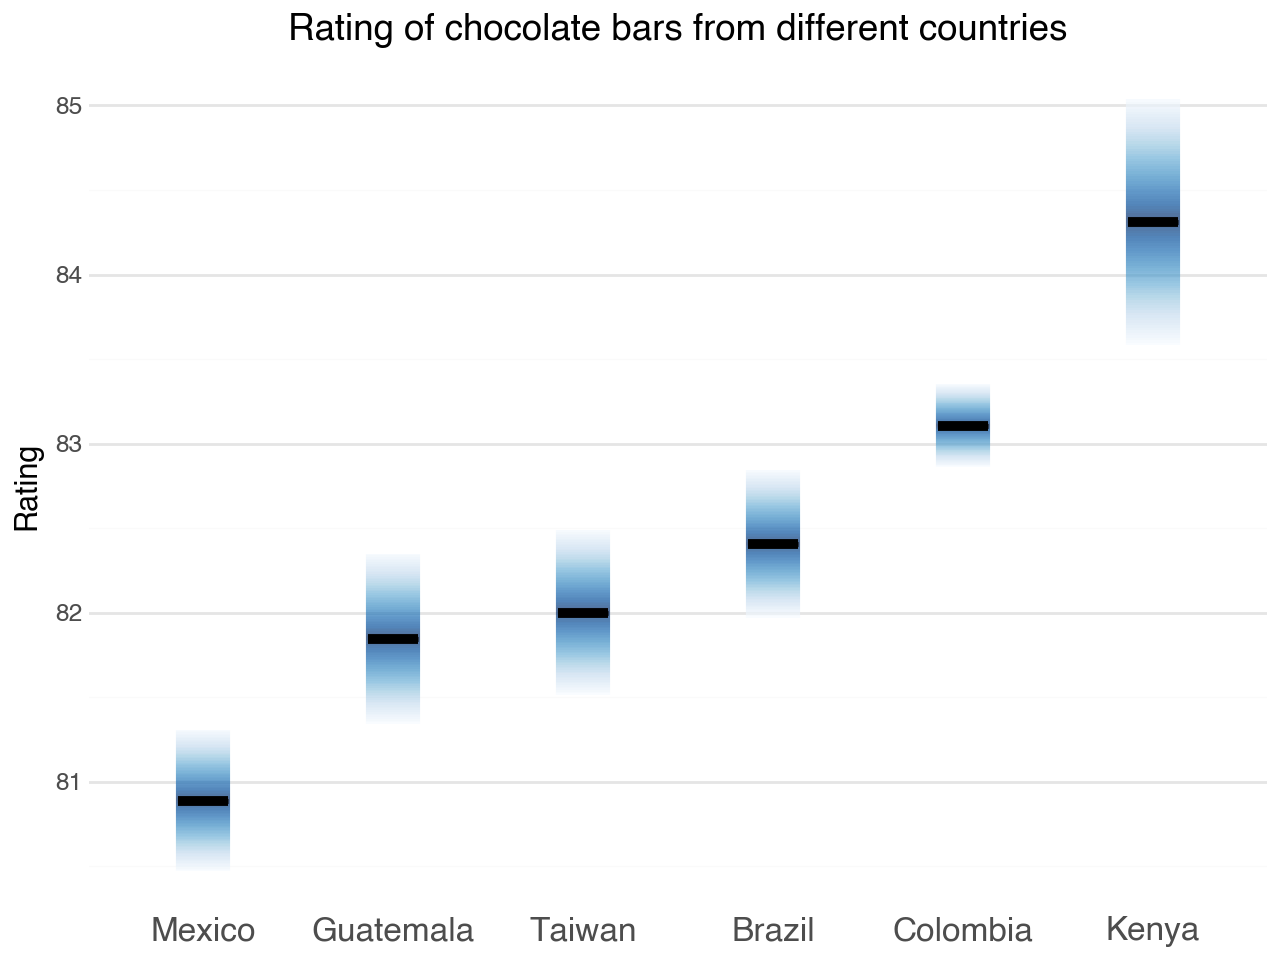

In [6]:
# Insert code here for visual 2
# Erik

data_fuzzy_tmp = CIs.query("CI_percent == '99%'")
data_fuzzy_80 = CIs.query("CI_percent == '80%'")

line_color = np.concatenate([np.linspace(0, 50, 50), np.linspace(50, 0, 50)])
data_fuzzy = pd.DataFrame()

for i in range(data_fuzzy_tmp.shape[0]):
    val_min, val_max = data_fuzzy_tmp["CI_low"].values[i], data_fuzzy_tmp["CI_high"].values[i]
    df_tmp = pd.DataFrame({"val_line" : np.linspace(val_min, val_max, 100), 
                        "color_line" : line_color}) 
    df_tmp["country_of_origin"] = data_fuzzy_tmp["country_of_origin"].values[i]
    data_fuzzy = pd.concat([data_fuzzy, df_tmp])


data_fuzzy["country_of_origin"] = pd.Categorical(data_fuzzy["country_of_origin"], categories=countries, ordered=True)


(
    ggplot(data_fuzzy, aes("country_of_origin", "val_line"))
        + geom_line(aes(color="color_line"), size=11.0, alpha=0.7)
        + geom_crossbar(data=data_fuzzy_80, mapping=aes(y = "total_cup_pointsmean", ymin = "total_cup_pointsmean", ymax = "total_cup_pointsmean"), width=0.26, size=1.0)
        + scale_color_cmap("Blues")
        + labs(x = "", y = "Rating", title = "Rating of chocolate bars from different countries")
        + theme_minimal()
        + theme(legend_position="none")
        + theme(panel_grid_major_x=element_blank(),
              axis_text_x = element_text(size=12))
)

# Remember to print the visual 

### Question 2.3

Frequency graphs are a powerful tool for visualising probabilities. On Canvas, I have uploaded an image of such a graph. Recreate it (you do not have to recreate the colours perfectly). The figure might look strange when rendered in Jupyter (then, it is better to save it to disk and see how it looks like),

In [18]:
# Insert code here 
# Remember to print the visual 

### Question 2.4

There are different ways to visualise curve fits. One is the fan plot (see lecture 6). On Canvas, I have uploaded a fan plot and associated dataset; use this dataset to recreate the visual.

**Note** - Hypothetical outcomes are generated via bootstraping, for computational speed it might be worthwhile to downsample the hypothetical outcomes.

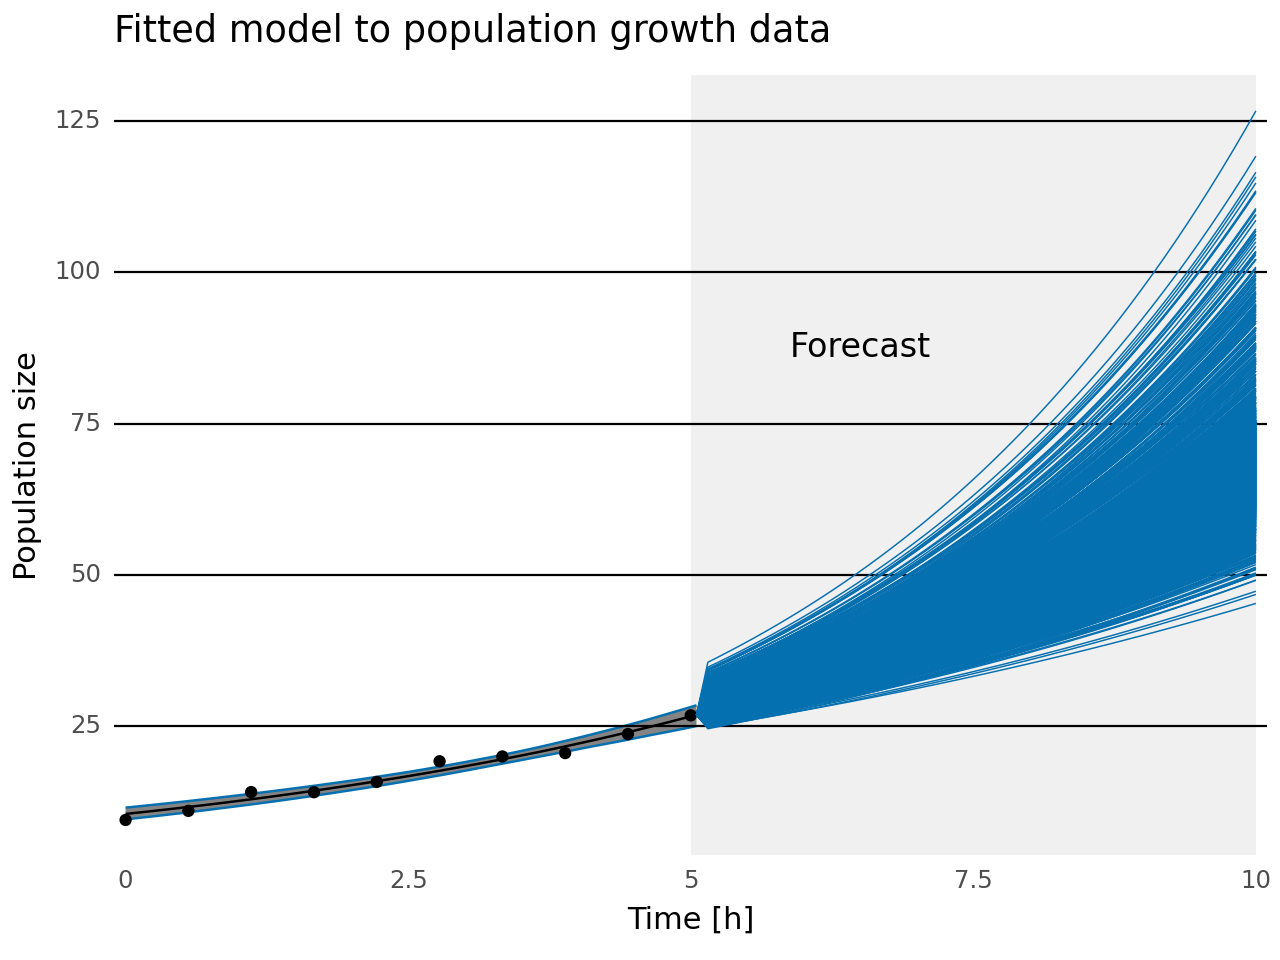

<Figure Size: (640 x 480)>

In [7]:
# Insert code here 
# Remember to print the visual 
#Yixuan
data_obs = pd.read_csv("Data_obs.csv")
data_fit = pd.read_csv("Fit_fan.csv")
data_pre = pd.read_csv("Pred_funnel.csv")

data_fit_90 = data_fit.query("Confidence_level == '90%'")

col_use = ["#0570b0", "#74a9cf", "#d0d1e6"]
p1 = (ggplot(data_fit_90, aes("t"))
    + geom_rect(aes(xmin=5.0, xmax=10.0, ymin=-np.Inf, ymax=np.Inf), fill="#f0f0f0", alpha=1.0)
    + geom_ribbon(aes(ymin = "Lower_CI", ymax="Upper_CI"), alpha=0.6, color=col_use[0])
    + geom_point(data=data_obs, mapping=aes("t", "N"))
    + geom_line(aes("t", "median"))
    + geom_line(data=data_pre, mapping=aes("t", "N_pred", group="index"), size=0.3, color=col_use[0])
    + annotate("text", x = 6.5, y = 87.5, label = "Forecast", size=12)
    + labs(x = "Time [h]", y = "Population size", title = "Fitted model to population growth data")
    + scale_x_continuous(expand=(0.0, 0.1))
    + scale_fill_manual(values = col_use[::-1], name="Confidence level")
    + theme_minimal()
    + theme(panel_grid_major_x=element_blank(), 
            panel_grid_minor_x=element_blank(), 
            panel_grid_major_y=element_line(color="black"), 
            panel_grid_minor_y=element_blank(),
            panel_ontop=True))
p1

## Part 2: Storytelling with data

## Storytelling with data

For this part reading chapter 20 in [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/) can help. An important part for making people interact with your visual is that it looks good, therefore, for this part I will also judge the aesthetics of the visual, as well as how efficiently it conveys its main message.

### Question 1.1

To make a visual accessible it is important to think like a designer - and a key feature here is to cleverly use highlighting and text annotations. An example of a well-designed visual is the Goal-attainment visual shown in the lecture, to practice annotations recreate it. The dataset is on Canvas. 

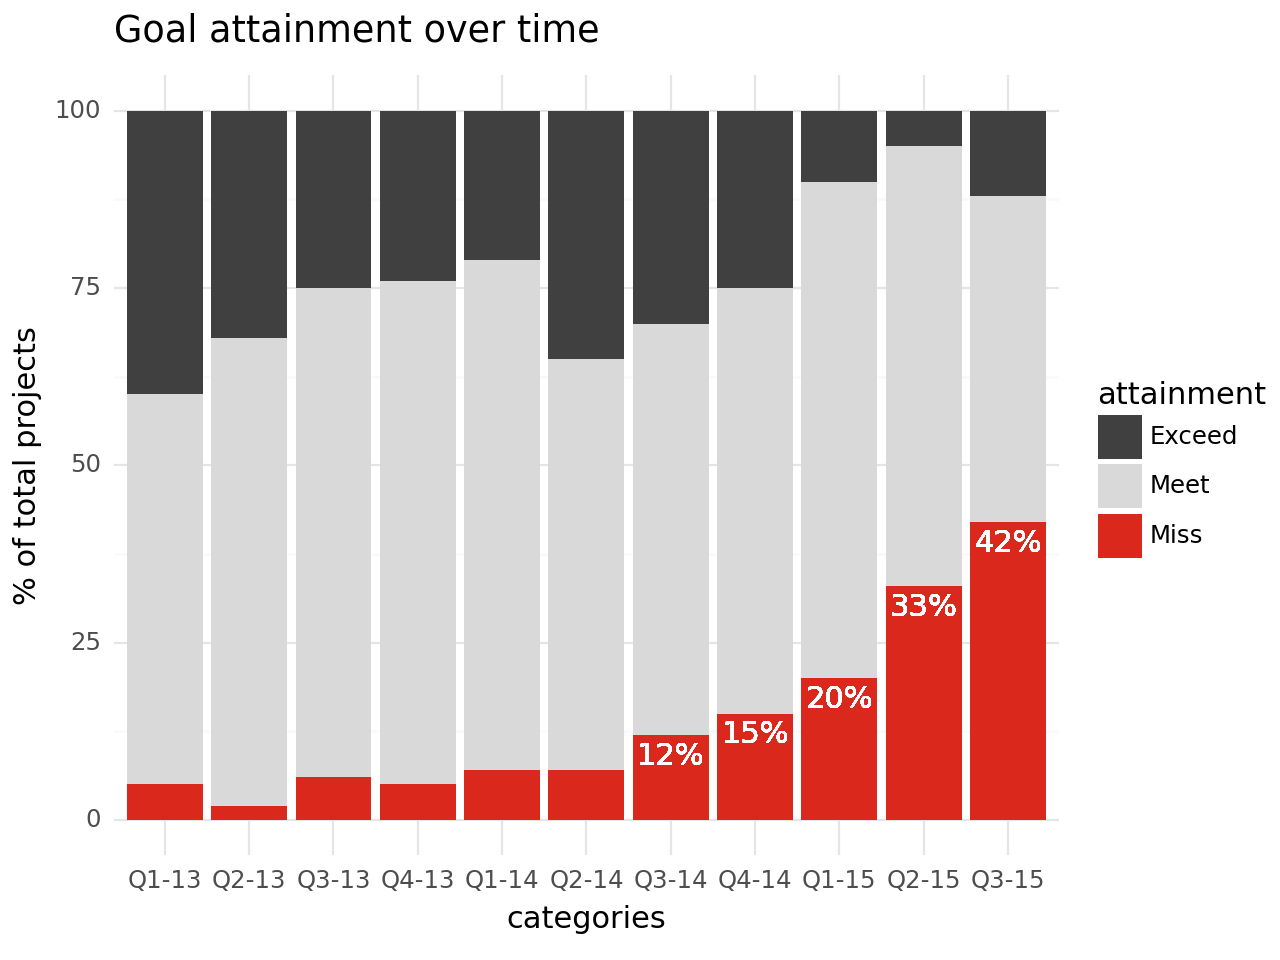

<Figure Size: (640 x 480)>

In [8]:
# Insert code here 
#Yixuan
data_q11 = pd.read_csv("Goal_data.csv")

order = [
    "Q1-13", "Q2-13", "Q3-13", "Q4-13",
    "Q1-14", "Q2-14", "Q3-14", "Q4-14",
    "Q1-15", "Q2-15", "Q3-15"
]

data_q11["categories"] = pd.Categorical(
    data_q11["categories"],
    categories=order,
    ordered=True
)

color_use= ["#404040", "#d9d9d9", "#DA291C"]
p = (ggplot(data_q11, aes("categories", "value", fill = "what"))
    + geom_bar(stat = "identity")
    + geom_text(x = 7, y = 9, label = "12%", color="white")
    + geom_text(x = 8, y = 12, label = "15%", color="white")
    + geom_text(x = 9, y = 17, label = "20%", color="white")
    + geom_text(x = 10, y = 30, label = "33%", color="white")
    + geom_text(x = 11, y = 39, label = "42%", color="white")
    + scale_fill_manual(values = color_use)
    + labs(y = "% of total projects", fill= "attainment", title = "Goal attainment over time")
    + theme_minimal())
p
# Remember to print the visual 

**Briefly comment on why red is a good choice of colour in this visual.**

_Brief motivation_
#Yixuan
Appropriate colors can convey tone, so red in this visual represents missing, making the highlight more noticeable.

### Question 1.2

During the lecture, I gave the Spanish unemployment data a long needed makeover - specifically I made it accessible for a wider audience. Choose any visual from the slides in lecture 1-6, decide upon a point you want to make, and use the lessons from the Story telling lecture to make that point accessible. 

Provide motivation to how the changes to the visual has made it more accessible.

In [106]:
data_gbg_weather = pd.read_csv("Weather_tidy-1.csv")
data_2020_summer = data_gbg_weather.query("(month == 'Jun' or month == 'Jul' or month == 'Aug') and year == 2020 and hour_of_day == 12")

p1 = (ggplot(data_2020_summer, aes("Temperature"))
    + geom_tile(color="white") 
  #+ scale_y_discrete(limits = pos)  
  + scale_fill_cmap("rainbow")
  + theme_minimal())
p1

KeyError: 'y'

_Brief motivation_

### Question 1.3

On Canvas I have uploaded a made-up pie chart example from a summer pilot program, where student prior and after the program were asked how excited they were about doing science. The program was a success, but, a pie-chart is not a good way to visualize the data. Using lessons from the lecture, improve the visual, such that a wide audience can identify that the program was a success. 

In the new visual make use of proper highlighting, annotations, a good title, and choose a good form of visualisation. The new visual should include all the data used in the pie chart.

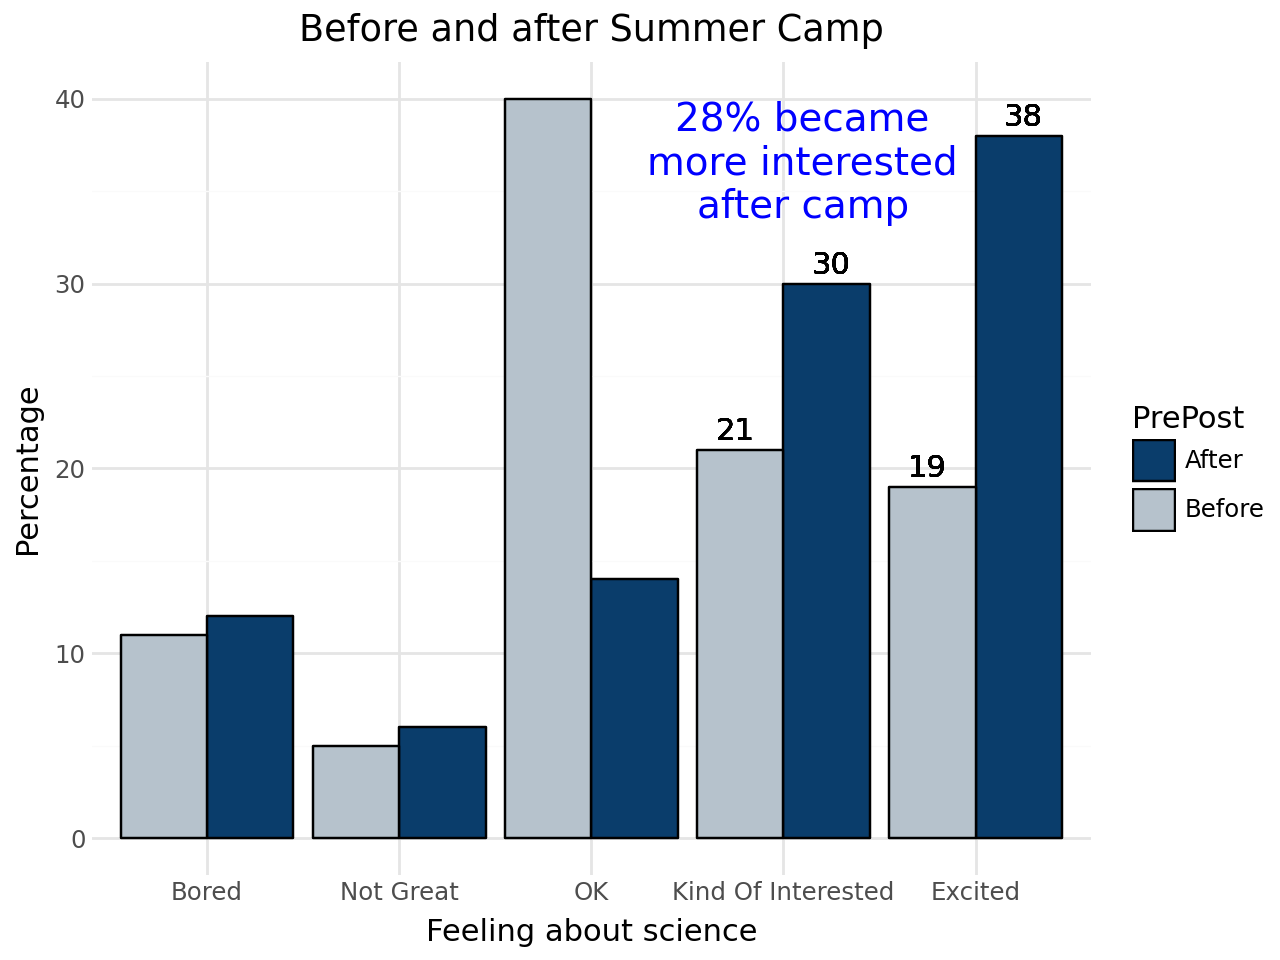

In [92]:
#Elis
data_q13 = pd.DataFrame({"Excitement" : ["Bored", "Bored", "Not Great", "Not Great", "OK", "OK", "Kind Of Interested", "Kind Of Interested", "Excited", "Excited"],
                      "Percentage" : [11, 12, 5, 6, 40, 14, 21, 30, 19, 38],
                      "PrePost" : ["0", "1", "0", "1", "0", "1", "0", "1", "0", "1"], 
                      "Better" : ["Before", "After", "Before", "After", "Before", "After", "Before", "After", "Before", "After"]})

order = ["Bored", "Not Great", "OK", "Kind Of Interested", "Excited"]

data_q13["Excitement"] = pd.Categorical(
    data_q13["Excitement"],
    categories=order,
    ordered=True
)

col_use = ["#0A3D6B", "#B6C2CC"]

p2 = (ggplot(data_q13, aes("Excitement", "Percentage", group="PrePost", fill="Better"))
    + geom_bar(stat="identity", position="dodge", color="black")
    + geom_text(aes(x = 3.75, y = 22, label = "21"))
    + geom_text(aes(x = 4.25, y = 31, label = "30"))
    + geom_text(aes(x = 4.75, y = 20, label = "19"))
    + geom_text(aes(x = 5.25, y = 39, label = "38"))
      + annotate(
        "text",
        x=4.1,
        y=36.5,
        label="28% became\nmore interested\nafter camp",
        color="blue",
        size=14,
    )
    + scale_fill_manual(values=col_use)
    + labs(x = "Feeling about science", fill = "PrePost", title = "Before and after Summer Camp")
    + theme_minimal())

p2

### Question 1.4

Clutter is something we want to remove. On Canvas I have uploaded a visual on performance index for *Our Business* compared to other companies. Improve this visual such that it becomes easy to see how *Our Business* compares against the other companies for each category.

Provide a brief motivation to why your new visual is accessible.

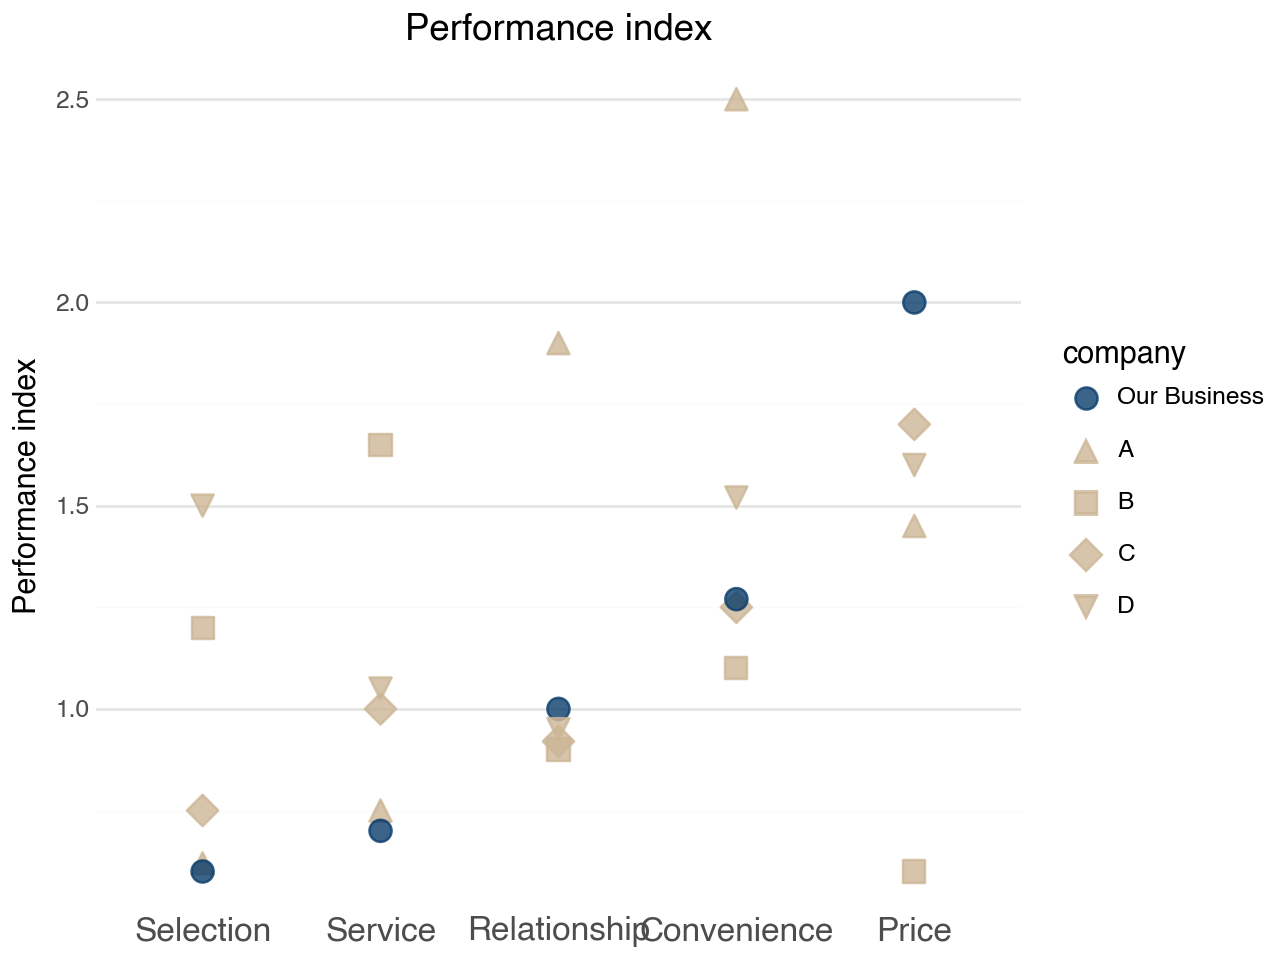

In [10]:
# Insert code here 
# Erik

data_business = pd.read_csv("Performance_index.csv")

col_highlight = ["#0A3D6B", "#CCB696", "#CCB696", "#CCB696", "#CCB696", "#CCB696", "#CCB696"]

companies = ["Our Business", "A", "B", "C", "D"]
criterias = ["Selection", "Service", "Relationship", "Convenience", "Price"]
data_business["company"] = pd.Categorical(data_business["company"], categories=companies, ordered=True)
data_business["criteria"] = pd.Categorical(data_business["criteria"], categories=criterias, ordered=True)

(
    ggplot(data_business, aes("criteria", "value", shape="company"))
        + geom_point(aes("criteria", "value", fill="company", color="company"), size = 4.0, alpha = 0.8, )
        + scale_fill_manual(values = col_highlight)
        + scale_color_manual(values = col_highlight)
        + labs(x = "", y = "Performance index", title = "Performance index")
        + theme_minimal()
        + theme(panel_grid_major_x=element_blank(),
              axis_text_x = element_text(size=12))
)

# Remember to print the visual 


# Brief motivation: 
# Shapes draw less attention than colors
# Reducing the colors and only highlighting "Our Business" makes for less clutter
# Sorting the criterias based on how well Our Business performed makes the total graph look less all over the place
# Removed unnecessary grid lines

## Tables

For this part reading chapter 22 in [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/) can help. 


### Question 2

A well-designed table may be a good tool to report exact amount of every value of your data. Following the lecture slides and the course book, redesign the table below to make it readable and easy to understand.

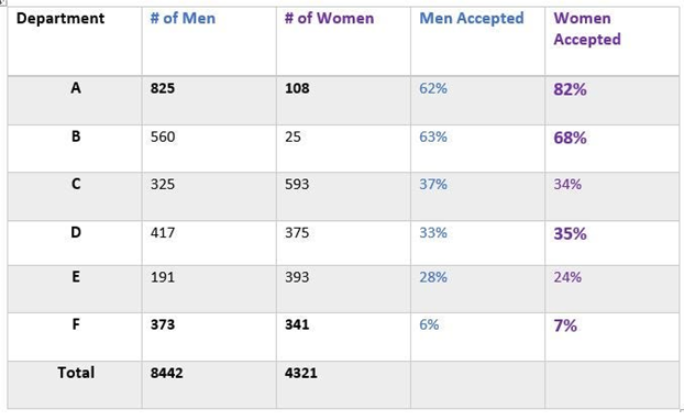

Taking a look at the table source (https://medium.com/@dexter.shawn/how-uc-berkeley-almost-got-sued-because-of-lying-data-aaa5d641f571) may help you in your decisions upon completing this task. 

You may use any software (except for ChatGTP and other AI tools). Desribe what you changed and why.

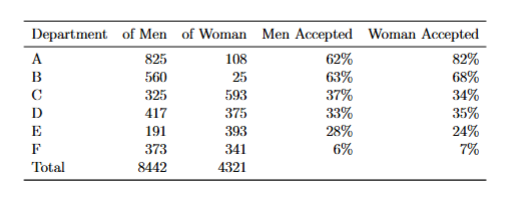

In [9]:
# Insert table here
#Yixuan
from IPython.display import Image
Image("table.png")

_Insert answer here_
#Yixuan
1. Deleted vertical lines.
2. Deleted horizontal lines between data rows.
3. Text columns are left aligned.
4. Number columns are right aligned.
5. The header fields are aligned with their data.